# 07.3 · Interpolation and document rectification

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain interpolation and document rectification using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[02 · Mathematics for Computer Vision](../../02-mathematics-for-computer-vision/README.md), [04 · OpenCV Fundamentals](../../04-opencv-fundamentals/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Geometric transformations move coordinates rather than directly changing intensity. A camera sees perspective, while image editing may only need translation or rotation. Separating coordinate mapping from interpolation explains why correct geometry can still produce blurry pixels.

## 2. Intuition

Nearest-neighbor chooses one sample; bilinear interpolation blends four samples. Interpolation does not recover lost detail. Document rectification estimates a homography from ordered page corners and resamples the page into a rectangle. Nonplanar pages, lens distortion and inaccurate corners violate the simple model.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 7
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
\tilde p\prime=H\tilde p,\qquad p\prime=(q_x/q_z,q_y/q_z)
$$

p is an input point, the tilde appends a homogeneous one, H is a 3×3 map and q is the resulting homogeneous vector. Translation by (3,−2) sends (4,5) to (7,3). Divide by the third coordinate after a perspective map.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
point = np.array([4.0, 5.0, 1.0])
H = np.array([[1.0, 0.0, 3.0], [0.0, 1.0, -2.0], [0.0, 0.0, 1.0]])
q = H @ point
xy = q[:2] / q[2]
assert np.allclose(xy, [7, 3])
print(xy)

[7. 3.]


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The reference normalizes point clouds, builds the DLT design matrix, takes the last right singular vector and denormalizes H. OpenCV warpPerspective then performs sampling with that matrix.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def transformations(lesson, seed, amount):
    image=picture(seed)
    if lesson==0:
        matrix=np.float32([[1,0,8*amount],[0,1,5]])
        output=cv2.warpAffine(image,matrix,(96,96))
        return Result('07 · Translation and interpolation',{'Input':image,'Warped':output,'Flip':image[:,::-1]},metrics={'translation_x_px':8*amount})
    source=np.float32([[5,5],[85,8],[83,82],[10,87]])
    target=np.float32([[10,10],[80,10],[80,80],[10,80]])
    h=fit_homography(source,target)
    output=cv2.warpPerspective(image,h,(96,96))
    if lesson==2:
        output=cv2.warpAffine(image,cv2.getRotationMatrix2D((48,48),15*amount,1),(96,96),flags=cv2.INTER_LINEAR)
    error=np.linalg.norm(apply_homography(source,h)-target,axis=1).mean()
    return Result('07 · Homogeneous coordinates and perspective',{'Input':image,'Warped output':output,'Homography coefficients':h},metrics={'point_reprojection_error_px':float(error)})

{
  "point_reprojection_error_px": 3.69890987290992e-14
}



## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/geometry.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.geometry import fit_homography

display(Code(inspect.getsource(fit_homography), language="python"))

def fit_homography(source, destination):
    """Normalized direct linear transform for at least four point pairs."""
    source, destination = np.asarray(source, float), np.asarray(destination, float)
    if source.shape != destination.shape or len(source) < 4:
        raise ValueError('Need four or more paired xy points.')
    def normalize(points):
        center = points.mean(0)
        scale = np.sqrt(2)/max(np.linalg.norm(points-center, axis=1).mean(), 1e-12)
        transform = np.array([[scale, 0, -scale*center[0]], [0, scale, -scale*center[1]], [0, 0, 1]])
        return apply_homography(points, transform), transform
    a, ta = normalize(source); b, tb = normalize(destination)
    design = []
    for (x, y), (u, v) in zip(a, b, strict=True):
        design.extend([[-x, -y, -1, 0, 0, 0, u*x, u*y, u],
                       [0, 0, 0, -x, -y, -1, v*x, v*y, v]])
    _, _, vt = np.linalg.svd(design)
    h = np.linalg.inv(tb) @ vt[-1].reshape(3, 3) @ ta
    return h/h[2, 2]

## 8. Experiment

Perturb one corner by two pixels and visualize the interior displacement. Compare nearest and bilinear interpolation on a checkerboard.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "point_reprojection_error_px": 3.69890987290992e-14
  },
  "second_seed": {
    "point_reprojection_error_px": 3.69890987290992e-14
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

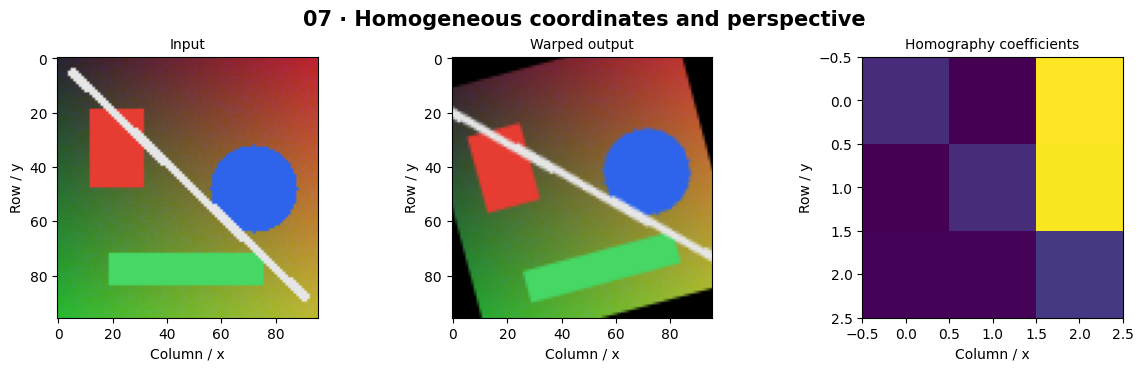

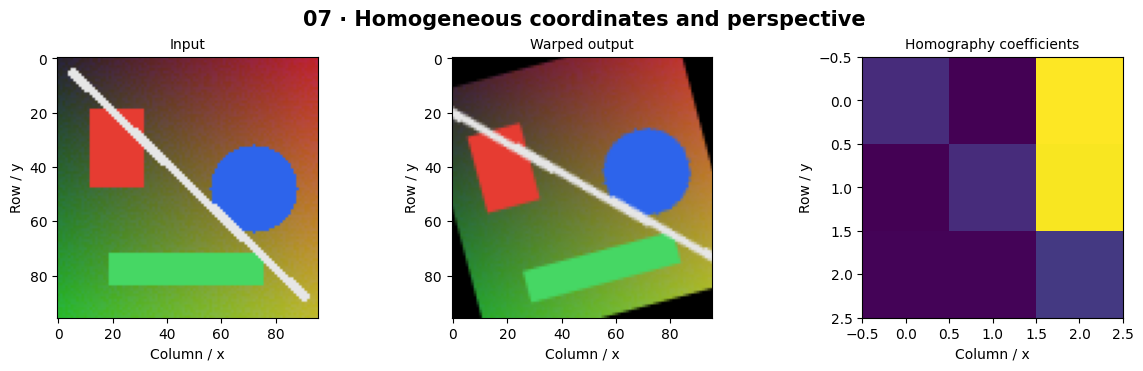

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Document Rectifier**. Map coordinates correctly and control resampling artifacts. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

A homography cannot generally align a scene with multiple depths under translation. Wrong corner order can fold the page across itself.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Perturb one corner by two pixels and visualize the interior displacement. Compare nearest and bilinear interpolation on a checkerboard.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a document scanner that detects corners, checks quadrilateral quality and exports a rectified image with a failure explanation.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Nearest-neighbor chooses one sample; bilinear interpolation blends four samples. Interpolation does not recover lost detail. Document rectification estimates a homography from ordered page corners and resamples the page into a rectangle. Nonplanar pages, lens distortion and inaccurate corners violate the simple model.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[08 · Color Spaces](../../08-color-spaces/README.md)

[Primary reference](https://docs.opencv.org/4.x/da/d6e/tutorial_py_geometric_transformations.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)